<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Comienzo por clonar mi repositorio de la materia en este colab

In [2]:
!git clone https://github.com/Fjmoya-uba/Taller-Procesamiento-Se-ales.git



Cloning into 'Taller-Procesamiento-Se-ales'...
remote: Enumerating objects: 659, done.
remote: Counting objects: 100% (140/140), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 659 (delta 94), reused 102 (delta 69), pack-reused 519 (from 1)
Receiving objects: 100% (659/659), 82.96 MiB | 23.20 MiB/s, done.
Resolving deltas: 100% (361/361), done.


Verifico que todo esté en orden

In [3]:

!ls -F Taller-Procesamiento-Se-ales/



apunte_taller.pdf   data/	  presentaciones/  TPs/
cronograma-tps.pdf  guia-tps.pdf  README.md


Me muevo a la carpeta que me interesa

In [4]:

%cd Taller-Procesamiento-Se-ales/TPs/


/content/Taller-Procesamiento-Se-ales/TPs


Bueno, comencemos con esto.


# Trabajo Práctico N°1 de TPS

Vamos con el set up

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Item A



### Punto 1

In [6]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

Reviso que se hayan cargado bien los datos:

In [7]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


### Punto 2


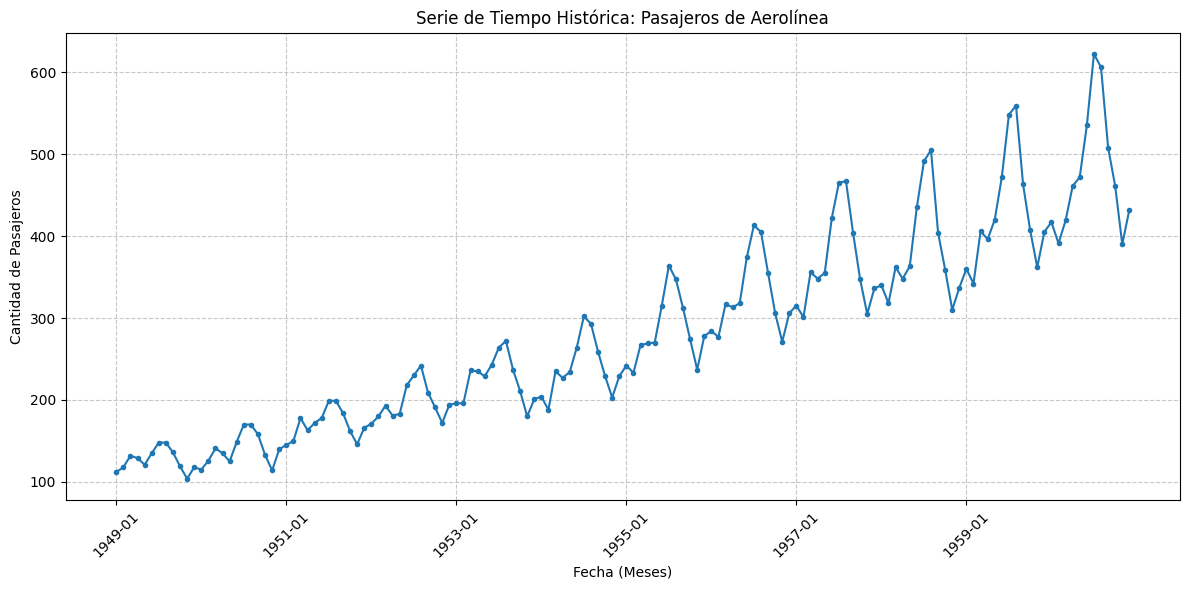

In [8]:
# Configuro el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Grafico la serie
# Uso df['Month'] para el eje X y df['Passengers'] para el eje Y
plt.plot(df['Month'], df['Passengers'], color='tab:blue', marker='.', linestyle='-')

# Agrego los nombres en los ejes y título
plt.xlabel('Fecha (Meses)')
plt.ylabel('Cantidad de Pasajeros')
plt.title('Serie de Tiempo Histórica: Pasajeros de Aerolínea')

# Mejoro la legibilidad del eje X (mostrando un año de por medio)
plt.xticks(df['Month'][::24], rotation=45)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Se está analizando el gráfico de la cantidad de pasajeros por mes de una aerolínea entre enero de 1949 y diciembre de 1960. A partir de la observación inicial, se puede identificar una tendencia creciente en la cantidad promedio de pasajeros a lo largo de los años, lo que indica que el volumen total de viajes fue aumentando con el tiempo.

Asimismo, se observan picos y caídas en distintos momentos de la serie. Sin embargo, a partir del gráfico no es posible identificar con precisión a qué meses corresponden esos máximos y mínimos. Contar con esa información permitiría analizar si existen meses en los que, históricamente, la demanda de viajes aéreos es mayor o menor que en otros.

Por este motivo, en la siguiente celda de código se realizará un análisis orientado a identificar los meses con mayor y menor cantidad de pasajeros. Además de realizar el gráfico de la media móvil.


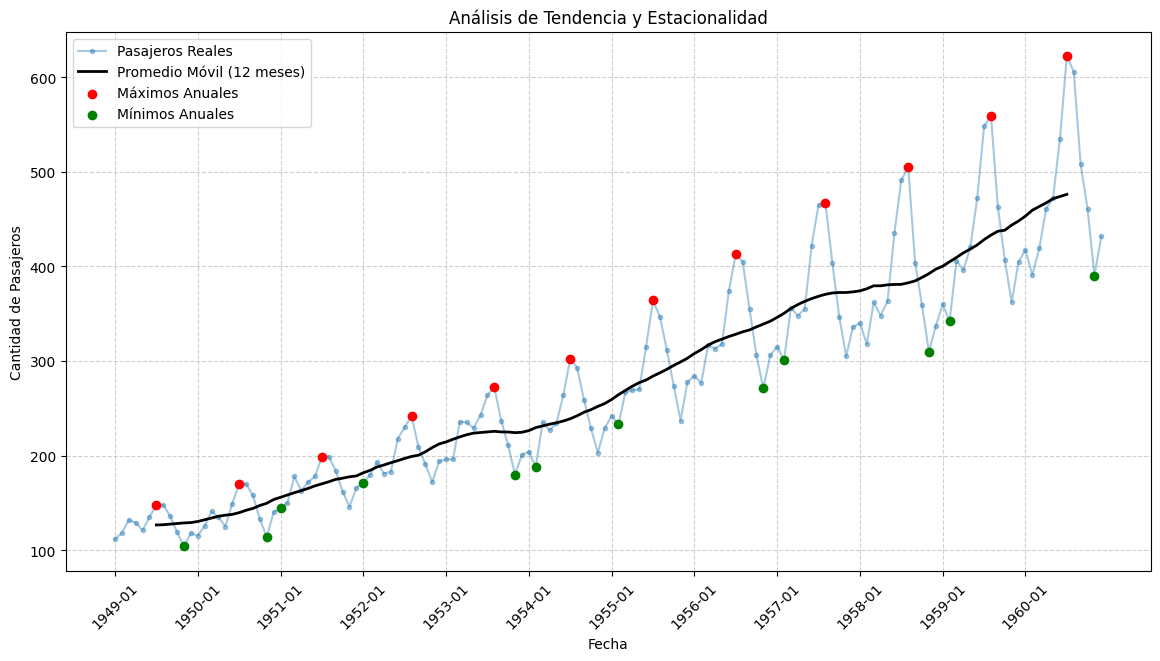

ANÁLISIS DE ESTACIONALIDAD HISTÓRICA
Meses de mayor demanda (Picos):
  * Julio: fue el pico máximo en 7 años.
  * Agosto: fue el pico máximo en 5 años.

Meses de menor demanda (Valles):
  * Noviembre: fue el punto más bajo en 6 años.
  * Febrero: fue el punto más bajo en 4 años.
  * Enero: fue el punto más bajo en 2 años.


In [10]:
# --- ANÁLISIS DE TENDENCIA (Punto a.2) ---

# -- Aplico un Promedio Móvil (Moving Average) para "suavizar" la serie: --

# 1. window=12: Promedia un año completo para eliminar el "ruido" de la estacionalidad (subas y bajas mensuales).
# 2. center=True: Centra el promedio en el mes del medio (mes 6 de 12) para que la línea no se desfase en el tiempo.
# 3. Resultado: Obtengo la tendencia real de crecimiento, ignorando los picos de vacaciones.
df['Promedio_Movil'] = df['Passengers'].rolling(window=12, center=True).mean()

# -- Busco los picos máximos y mínimos por año --
# Extraigo el año de la columna Month para agrupar
df['Year'] = df['Month'].str[:4]
max_per_year = df.loc[df.groupby('Year')['Passengers'].idxmax()]
min_per_year = df.loc[df.groupby('Year')['Passengers'].idxmin()]

# -- Grafico los resultados --
plt.figure(figsize=(14, 7))
plt.plot(df['Month'], df['Passengers'], label='Pasajeros Reales', alpha=0.4, color='tab:blue', marker='.')
plt.plot(df['Month'], df['Promedio_Movil'], label='Promedio Móvil (12 meses)', color='black', linewidth=2)

# Marco los picos
plt.scatter(max_per_year['Month'], max_per_year['Passengers'], color='red', label='Máximos Anuales', zorder=5)
plt.scatter(min_per_year['Month'], min_per_year['Passengers'], color='green', label='Mínimos Anuales', zorder=5)

plt.title('Análisis de Tendencia y Estacionalidad')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Pasajeros')
plt.xticks(df['Month'][::12], rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# -- Imprimo los resultados: --
# Diccionario para pasar de número a nombre de mes
nombres_meses = {
    '01': 'Enero', '02': 'Febrero', '03': 'Marzo', '04': 'Abril',
    '05': 'Mayo', '06': 'Junio', '07': 'Julio', '08': 'Agosto',
    '09': 'Septiembre', '10': 'Octubre', '11': 'Noviembre', '12': 'Diciembre'
}

print("ANÁLISIS DE ESTACIONALIDAD HISTÓRICA")

# Proceso los máximos
print("Meses de mayor demanda (Picos):")
max_counts = max_per_year['Month'].str[5:].value_counts()
for mes_num, cant in max_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el pico máximo en {cant} años.")

print("\nMeses de menor demanda (Valles):")
min_counts = min_per_year['Month'].str[5:].value_counts()
for mes_num, cant in min_counts.items():
    print(f"  * {nombres_meses[mes_num]}: fue el punto más bajo en {cant} años.")

Como se puede observar en los últimos resultados, se aprecia una clara tendencia creciente en la cantidad de pasajeros a lo largo de los 12 años analizados.

Por otro lado, a partir del análisis de los meses con mayor y menor cantidad de pasajeros, se puede inferir que estos datos probablemente corresponden a un país del hemisferio norte (posiblemente Estados Unidos). Durante los meses de verano (junio, julio y agosto) se registra un mayor número de viajes en avión, lo que podría explicarse por el período de vacaciones. En cambio, durante el invierno la demanda disminuye, con una caída particularmente marcada en noviembre. Esto podría deberse a que muchas personas evitan viajar en ese mes mientras se preparan para las fiestas de fin de año; posteriormente, en diciembre, la demanda vuelve a incrementarse levemente debido a celebraciones como Navidad y al inicio del período vacacional. Además, es razonable suponer que, en los meses más fríos, en general disminuye la disposición de las personas a viajar.

### Punto 3

Bueno, para el punto 3 del item a, el objetivo es transformar la serie de tiempo (una sola columna de datos) en una matriz de entrenamiento que el modelo de regresión lineal pueda entender.

Primero hay que tener en cuenta que la serie de datos tiene un comportamiento estacional de 12 meses. Es decir, lo que ocurre en un mes muchas veces está relacionado con lo que ocurrió durante el año anterior. Por esta razón, no conviene tratar cada dato como si fuera completamente independiente de los demás.

Para poder entrenar un modelo de predicción, es necesario transformar esta serie temporal (que es simplemente una lista de valores a lo largo del tiempo) en un conjunto de datos que el modelo pueda utilizar para aprender. Para lograrlo se utiliza una técnica llamada ventana deslizante (sliding window).

La idea es bastante simple. En lugar de mirar un solo mes, se toman 12 meses consecutivos y se usan como información de entrada. Esos 12 meses funcionan como “pistas” que le permiten al modelo entender cómo viene evolucionando la serie. Luego, el mes siguiente (el número 13) se utiliza como el valor que el modelo debe intentar predecir.

Por ejemplo, el modelo observa los datos desde enero hasta diciembre de un año y, con esa información, intenta predecir cuántos pasajeros habrá en enero del año siguiente.

Una vez hecho esto, la ventana se mueve un mes hacia adelante y se repite el proceso. Ahora el modelo toma los datos desde febrero hasta enero del año siguiente, e intenta predecir el valor de febrero. Este procedimiento continúa avanzando mes a mes a lo largo de toda la serie.

De esta manera se generan muchas muestras de entrenamiento a partir de una única serie histórica. En cada nueva muestra, la mayoría de los meses se repiten (porque la ventana solo se mueve un mes), pero el objetivo a predecir cambia. Esto permite construir un conjunto de datos mucho más grande y útil para entrenar el modelo.

In [11]:
# --- CONSTRUCCIÓN DEL DATASET (Punto a.3) ---

# Pasamos los datos de la columna 'Passengers' a un array de NumPy
serie = df['Passengers'].values

X = []
y = []
ventana = 12  # Los 12 meses anteriores para predecir el siguiente

# Generamos los solapamientos
for i in range(len(serie) - ventana):
    # Tomamos desde i hasta i+12 como features (X)
    X.append(serie[i : i + ventana])
    # El valor en i+12 es nuestro objetivo o target (y)
    y.append(serie[i + ventana])

# Convertimos las listas en arrays de NumPy
X = np.array(X)
y = np.array(y)

# Verificamos las dimensiones
print(f"Dimensiones de la matriz de entrada (X): {X.shape}") # Debería ser (132, 12)
print(f"Dimensiones del vector de salida (y): {y.shape}")     # Debería ser (132,)

# Ejemplo de la primera muestra
print("\nPrimera muestra de entrenamiento:")
print(f"X[0] (Meses 1 al 12): {X[0]}")
print(f"y[0] (Mes 13): {y[0]}")

Dimensiones de la matriz de entrada (X): (132, 12)
Dimensiones del vector de salida (y): (132,)

Primera muestra de entrenamiento:
X[0] (Meses 1 al 12): [112 118 132 129 121 135 148 148 136 119 104 118]
y[0] (Mes 13): 115


## Item B


### Punto 1
